In [1]:
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
import kcorrect.kcorrect
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

### K Correction

En este algoritmo, la corrección k se realiza sobre la Muestra Principal de Galaxias (MSG) de SDSS utilizando el código KCORRECT (M. Blanton).

https://kcorrect.readthedocs.io/en/5.1.1/index.html

##### Work with the data

A continuación se cargarán los datos de las magnitudes de galaxias pertenecientes a la MSG, se descartan los valores que puedan afectar el ajuste y se grafican las distribuciones resultantes.

In [2]:
MSG = pd.read_csv('MSG.csv')

In [4]:
MSG.describe()

,objID,redshift,modelMag_u,modelMagErr_u,extinction_u,modelMag_g,modelMagErr_g,extinction_g,modelMag_r,modelMagErr_r,extinction_r,modelMag_i,modelMagErr_i,extinction_i,modelMag_z,modelMagErr_z,extinction_z
count,4.511920e+05,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000,451192.000000
mean,5.878154e+17,0.106160,19.323185,-0.053327,0.157107,17.694881,-0.036077,0.115598,16.842645,0.005711,0.083841,16.416815,0.006066,0.063574,16.015100,-0.075174,0.045075
std,1.807697e+14,0.046309,36.545389,36.463173,0.096939,21.102996,21.051891,0.071327,0.681487,0.001854,0.051732,0.680443,0.028864,0.039227,29.827599,29.771807,0.027812
min,5.877230e+17,0.030000,-9999.000000,-9999.000000,0.015224,-9999.000000,-9999.000000,0.011202,11.968400,0.001616,0.008124,11.611060,0.001627,0.006161,-9999.000000,-9999.000000,0.004368
25%,5.877321e+17,0.071358,18.867270,0.041149,0.091598,17.317967,0.005851,0.067397,16.497530,0.004540,0.048882,16.077240,0.004554,0.037066,15.757867,0.009855,0.026280
50%,5.877389e+17,0.099826,19.535880,0.063827,0.134588,17.888150,0.007690,0.099029,17.018980,0.005717,0.071824,16.587025,0.005724,0.054462,16.267290,0.013028,0.038614
75%,5.877429e+17,0.135472,20.130620,0.096900,0.197751,18.299762,0.009643,0.145504,17.360920,0.006722,0.105531,16.922070,0.006776,0.080021,16.602240,0.016147,0.056736
max,5.888489e+17,0.299798,30.842740,9.691940,1.776414,28.652290,6.875753,1.307069,18.528120,0.048812,0.947995,28.298760,5.652611,0.718836,27.289790,5.440267,0.509664


In [3]:
MSG = MSG[(MSG['modelMag_u']>0)&
          (MSG['modelMagErr_u']>0)&
          (MSG['modelMag_g']>0)&
          (MSG['modelMagErr_g']>0)&
          (MSG['modelMag_r']>0)&
          (MSG['modelMagErr_r']>0)&
          (MSG['modelMag_z']>0)&
          (MSG['modelMagErr_z']>0)&
          (MSG['modelMag_i']>0)&
          (MSG['modelMagErr_i']>0)]

In [4]:
MSG

,objID,redshift,modelMag_u,modelMagErr_u,extinction_u,modelMag_g,modelMagErr_g,extinction_g,modelMag_r,modelMagErr_r,extinction_r,modelMag_i,modelMagErr_i,extinction_i,modelMag_z,modelMagErr_z,extinction_z
0,587722981744902300,0.088799,19.91550,0.063814,0.181282,17.97751,0.007791,0.133385,17.02798,0.005058,0.096742,16.57997,0.005046,0.073357,16.22250,0.010181,0.052011
1,587722981744967759,0.146446,20.71007,0.124666,0.178553,18.48612,0.010869,0.131377,17.35504,0.006009,0.095286,16.88805,0.005959,0.072252,16.55814,0.012471,0.051228
2,587722981744967771,0.152083,20.55222,0.106713,0.178781,18.53510,0.010961,0.131545,17.40557,0.006071,0.095408,16.92069,0.005953,0.072345,16.55273,0.012153,0.051293
3,587722981744967809,0.147064,20.01891,0.063431,0.171515,18.19122,0.009128,0.126199,17.32281,0.006673,0.091530,16.94052,0.007052,0.069405,16.67728,0.013312,0.049209
4,587722981744967811,0.143732,19.36153,0.043162,0.171860,18.04230,0.008239,0.126453,17.30386,0.005816,0.091714,16.83807,0.005826,0.069544,16.58002,0.013282,0.049308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451187,588848901007933476,0.034861,16.92802,0.014284,0.270167,15.30444,0.002678,0.198787,14.61557,0.002387,0.144177,14.26663,0.002553,0.109325,14.00773,0.004705,0.077513
451188,588848901007933710,0.107974,18.97975,0.059680,0.249048,17.58811,0.006549,0.183247,16.82364,0.005320,0.132906,16.43360,0.006031,0.100779,16.16250,0.014108,0.071453
451189,588848901008064671,0.038900,17.42803,0.016235,0.257063,15.54256,0.002684,0.189144,14.68228,0.002259,0.137183,14.26233,0.002344,0.104022,13.95460,0.003814,0.073753
451190,588848901008064775,0.052316,18.26569,0.026392,0.281060,16.96636,0.005081,0.206801,16.41017,0.004230,0.149989,16.11516,0.004974,0.113733,15.90681,0.011768,0.080638


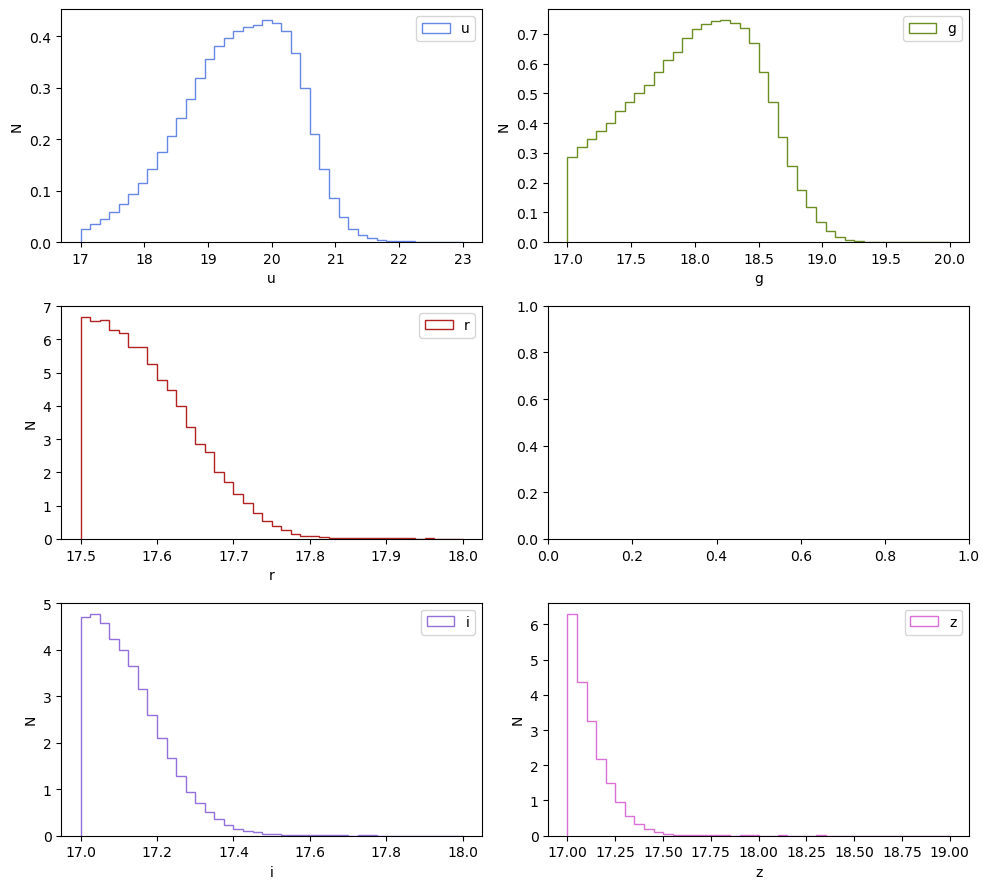

In [7]:
#disposición de los histogramas
fig, axs = plt.subplots(3, 2, figsize=(10, 9))  #2 fila, 3 columnas

#Plot 1 : u,g
axs[0, 0].hist(MSG['modelMag_u'], bins=40, range=(17, 23), color='royalblue', alpha=0.8, label='u', histtype='step', density=True)
axs[0, 0].set_xlabel('u')
axs[0, 0].set_ylabel('N')
axs[0, 0].legend()
#
axs[0, 1].hist(MSG['modelMag_g'], bins=40, color='olivedrab', alpha=1, label='g', histtype='step', range=(17, 20), density=True)
axs[0, 1].set_xlabel('g')
axs[0, 1].set_ylabel('N')
axs[0, 1].legend()

#
axs[1, 0].hist(MSG['modelMag_r'], bins=40, color='firebrick', alpha=1, label='r', histtype='step', range=(17.5, 18), density=True)
axs[1, 0].set_xlabel('r')
axs[1, 0].set_ylabel('N')
axs[1, 0].legend()

#Plot 2: y,z
axs[2, 0].hist(MSG['modelMag_i'], bins=40, color='mediumpurple', alpha=1, label='i', histtype='step', range=(17, 18), density=True)
axs[2, 0].set_xlabel('i')
axs[2, 0].set_ylabel('N')
axs[2, 0].legend()

#
axs[2, 1].hist(MSG['modelMag_z'], bins=40, color='orchid', alpha=1, label='z', histtype='step', range=(17, 19), density=True)
axs[2, 1].set_xlabel('z')
axs[2, 1].set_ylabel('N')
axs[2, 1].legend()

#ajustar el espacio entre los subplots
plt.tight_layout()

#mostrar
plt.show()

##### Definition of the parameters

Redshift, magnitudes que se convertiran en maggies, error en las magnitudes y extinción.

In [5]:
redshift = MSG['redshift']

In [6]:
mag = MSG[['modelMag_u', 'modelMag_g', 'modelMag_r', 'modelMag_i', 'modelMag_z']]

In [7]:
mag_err = MSG[['modelMagErr_u', 'modelMagErr_g', 'modelMagErr_r', 'modelMagErr_i', 'modelMagErr_z']]

In [8]:
extinction = MSG[['extinction_u', 'extinction_g', 'extinction_r', 'extinction_i', 'extinction_z']]

##### Use function to convert SDSS magnitudes to maggies

In [9]:
magg = kcorrect.utils.sdss_asinh_to_maggies(mag = mag, mag_err = mag_err, extinction = extinction)

##### Definition of the coeffs

In [10]:
maggies = magg[0]

In [11]:
ivar = magg[1]

In [12]:
responses = ['sdss_u0', 'sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0']
kc = kcorrect.kcorrect.Kcorrect(responses=responses)

In [13]:
coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)


 NNLS quitting on iteration count.

 NNLS quitting on iteration count.


##### Calculate the k corrections and absolute magnitudes

In [14]:
k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

In [15]:
k

array([[ 0.34403875,  0.26074302,  0.12298186,  0.06306707,  0.05759904],
       [ 0.60302866,  0.5179493 ,  0.18472788,  0.10809202,  0.06303394],
       [ 0.6286185 ,  0.5270455 ,  0.20995863,  0.11474054,  0.08742559],
       ...,
       [ 0.13719721,  0.10453953,  0.04461266,  0.02998765,  0.01918867],
       [ 0.14076082,  0.06242667,  0.05594682, -0.02488125, -0.00435846],
       [ 0.1178567 ,  0.07481743,  0.06152232,  0.01279737,  0.01719987]],
      dtype=float32)

In [16]:
ku = k[:, 0]

In [17]:
kg = k[:, 1]

In [18]:
kr = k[:, 2]

In [19]:
ki = k[:, 3]

In [20]:
kz = k[:, 4]

In [21]:
absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

In [22]:
absmag_u = absmag[:, 0]

In [23]:
absmag_g = absmag[:, 1]

In [24]:
absmag_r = absmag[:, 2]

In [25]:
absmag_i = absmag[:, 3]

In [26]:
absmag_z = absmag[:, 4]

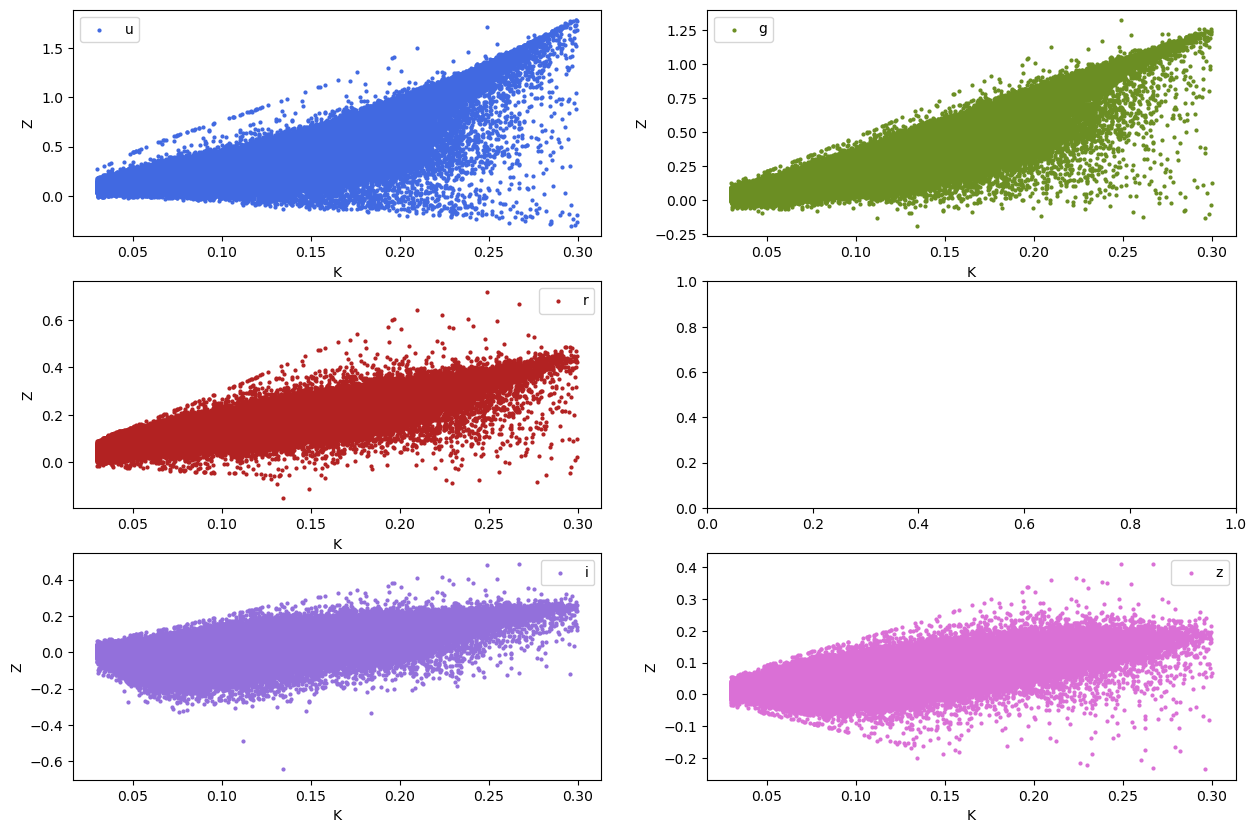

In [27]:
#plot z vs kcorrection

#Datos
kcorrect_u = ku
kcorrect_g = kg
kcorrect_r = kr
kcorrect_i = ki
kcorrect_z = kz
redshifts = redshift

#subplots
fig, axs = plt.subplots(3, 2, figsize=(15, 10))

#crear los graficos
axs[0, 0].scatter(redshifts, kcorrect_u, label='u', color='royalblue', s=4)
axs[0, 0].set_xlabel('K')
axs[0, 0].set_ylabel('Z')

axs[0, 1].scatter(redshifts, kcorrect_g, label='g', color='olivedrab', s=4)
axs[0, 1].set_xlabel('K')
axs[0, 1].set_ylabel('Z')

axs[1, 0].scatter(redshifts, kcorrect_r, label='r', color='firebrick', s=4)
axs[1, 0].set_xlabel('K')
axs[1, 0].set_ylabel('Z')

axs[2, 0].scatter(redshifts, kcorrect_i, label='i', color='mediumpurple', s=4)
axs[2, 0].set_xlabel('K')
axs[2, 0].set_ylabel('Z')

axs[2, 1].scatter(redshifts, kcorrect_z, label='z', color='orchid', s=4)
axs[2, 1].set_xlabel('K')
axs[2, 1].set_ylabel('Z')

#Labels y titulo
#fig.suptitle('Redshift vs Corrección K para cada filtro', y=0.9)
#fig.text(0.5, 0.04, 'z', ha='center', va='center')
#fig.text(0.06, 0.5, 'k(z)', ha='center', va='center', rotation='vertical')

#mostrar leyendas
for ax in axs.flat:
    if ax.has_data():
        ax.legend()
    
plt.subplots_adjust()

#mostrar gráfica
plt.show()

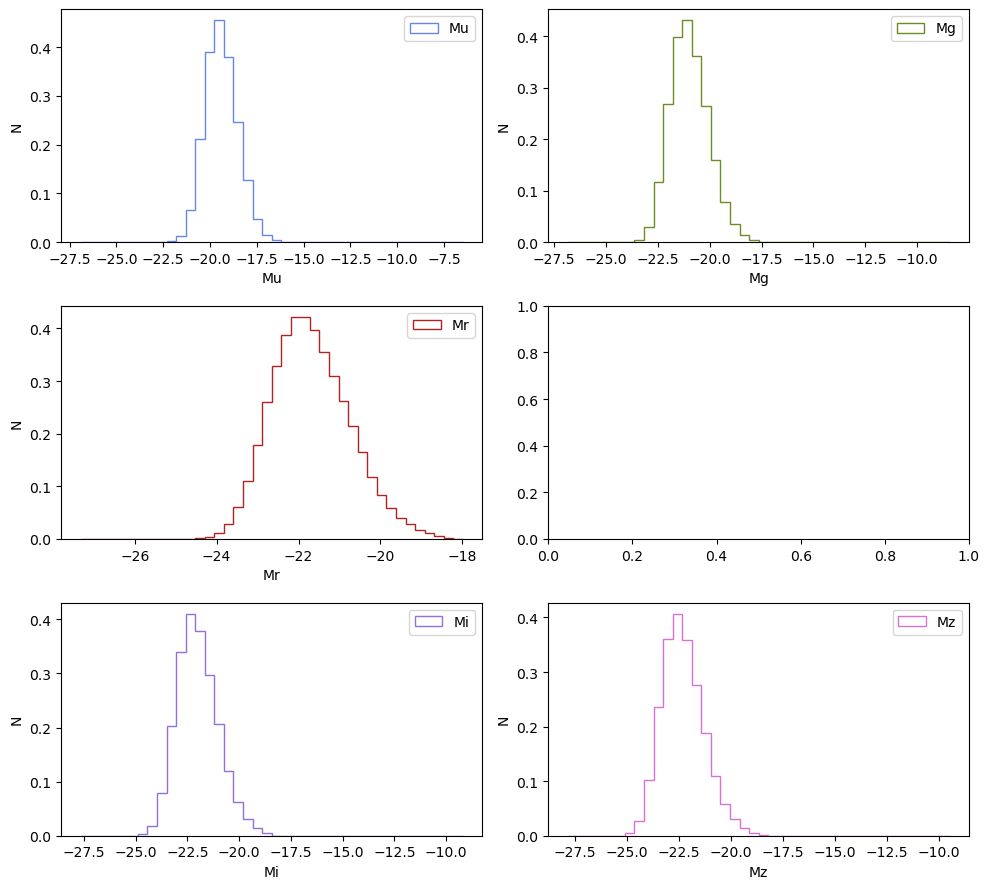

In [45]:
#disposición de los histogramas
fig, axs = plt.subplots(3, 2, figsize=(10, 9))  #2 fila, 3 columnas


#Plot 1 : u,g
axs[0, 0].hist(absmag_u, bins=40, color='royalblue', alpha=0.8, label='Mu', histtype='step', density=True)
axs[0, 0].set_xlabel('Mu')
axs[0, 0].set_ylabel('N')
axs[0, 0].legend()
#
axs[0, 1].hist(absmag_g, bins=40, color='olivedrab', alpha=1, label='Mg', histtype='step', density=True)
axs[0, 1].set_xlabel('Mg')
axs[0, 1].set_ylabel('N')
axs[0, 1].legend()

#
axs[1, 0].hist(absmag_r, bins=40, color='firebrick', alpha=1, label='Mr', histtype='step', density=True)
axs[1, 0].set_xlabel('Mr')
axs[1, 0].set_ylabel('N')
axs[1, 0].legend()

#Plot 2: y,z
axs[2, 0].hist(absmag_i, bins=40, color='mediumpurple', alpha=1, label='Mi', histtype='step', density=True)
axs[2, 0].set_xlabel('Mi')
axs[2, 0].set_ylabel('N')
axs[2, 0].legend()

#
axs[2, 1].hist(absmag_z, bins=40, color='orchid', alpha=1, label='Mz', histtype='step', density=True)
axs[2, 1].set_xlabel('Mz')
axs[2, 1].set_ylabel('N')
axs[2, 1].legend()

#ajustar el espacio entre los subplots
plt.tight_layout()

#mostrar
plt.show()

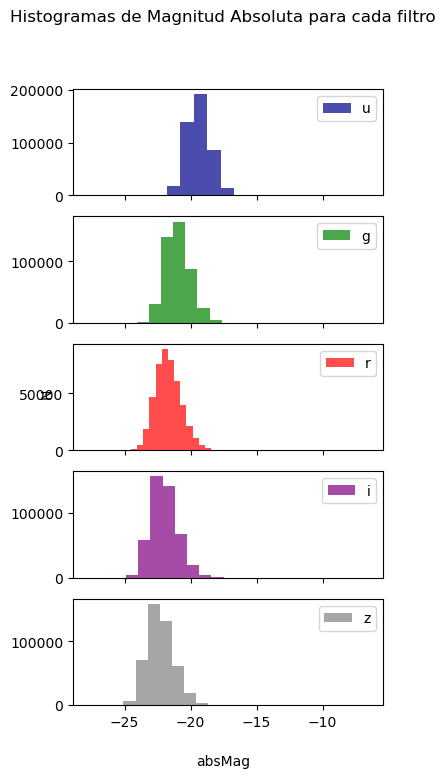

In [44]:
#plot z vs absmag

#Datos
absmag_u = absmag_u 
absmag_g = absmag_g
absmag_r = absmag_r
absmag_i = absmag_i
absmag_z = absmag_z
redshifts = redshift

# Subgráficos
fig, axs = plt.subplots(5, 1, figsize=(4, 8), sharex=True)

# Crear histogramas
axs[0].hist(absmag_u, bins=20, color='darkblue', alpha=0.7, label='u')
axs[1].hist(absmag_g, bins=20, color='green', alpha=0.7, label='g')
axs[2].hist(absmag_r, bins=20, color='red', alpha=0.7, label='r')
axs[3].hist(absmag_i, bins=20, color='purple', alpha=0.7, label='i')
axs[4].hist(absmag_z, bins=20, color='grey', alpha=0.7, label='z')

# Etiquetas y título
fig.suptitle('Histogramas de Magnitud Absoluta para cada filtro')
fig.text(0.5, 0.04, 'absMag', ha='center', va='center')
fig.text(0.06, 0.5, 'N', ha='center', va='center', rotation='vertical')

# Mostrar leyendas
for ax in axs:
    ax.legend()

# Mostrar gráfica
plt.show()



#### Absolute magnitudes without kcorrection

Definición de la cosmología y estima de distancias utilizando astropy.

In [31]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.2)

##### Distancia Comóvil (Along the Line-of-Sight))

La distancia comóvil ($D_{c}$) a lo largo de la línea de visión es la distancia que permanece constante a lo largo del tiempo para objetos que se desplazan con la expansión del Universo.

Se calcula mediante la siguiente integral:

$$D_C = D_H \int_{0}^{z} \frac{dz'}{E(z')}$$

donde:
* $D_H$: distancia de Hubble
* $z$: Es el *redshift* del objeto cuya distancia estamos calculando.
* $dz'$: Es un elemento diferencial de *redshift* a lo largo de la trayectoria de la luz.
* $E(z')$: Es una función que describe como cambia la tasa de expansión del Universo con el *redshift* en un modelo cosmológico dado. Se define como:

$$E(z) = \sqrt{\Omega_M (1 + z)^3 + \Omega_k (1 + z)^2 + \Omega_\Lambda}$$

Donde:
* $\Omega_M$, $\Omega_k$ y $\Omega_\Lambda$: parámetros de densidad

In [32]:
Comoving_dist = cosmo.comoving_distance(MSG['redshift'])

In [33]:
Comoving_dist

<Quantity [375.08208246, 612.72766701, 635.7085302 , ..., 165.6115442 ,
           222.26474953, 169.6581562 ] Mpc>

##### Comoving transverse distance

La distancia comóvil transversa ($D_M$) se refiere a la distancia comóvil entre dos eventos que tienen el mismo $z$ y están separados por un cierto ángulo $\theta$ en el cielo. 

Esta relación se expresa como:

\begin{equation}
    D_M = \theta D_C
\end{equation}

In [34]:
#distancia Comóvil Transversa (dM) - same as dC for flat cosmology
dM = cosmo.comoving_transverse_distance(MSG['redshift'])

In [35]:
dM

<Quantity [375.08208246, 612.72766701, 635.7085302 , ..., 165.6115442 ,
           222.26474953, 169.6581562 ] Mpc>

##### Luminosity distance

La distancia de luminosidad $D_L$ está relacionada con la distancia comóvil transversa $D_M$ a través del corrimiento al rojo $z$ mediante la siguiente expresión:

\begin{equation}
    D_L = (1 + z) D_M
\end{equation}

In [36]:
LD = cosmo.luminosity_distance(MSG['redshift'])

In [37]:
LD

<Quantity [408.38914634, 702.45918293, 732.3889906 , ..., 172.05376703,
           233.89272994, 176.42005167] Mpc>

In [38]:
print(' Min LD value:', np.min(LD), ',' , 'Max LD value', np.max(LD))

 Min LD value: 131.73498224838585 Mpc , Max LD value 1586.8578742482011 Mpc


##### Angular diameter distance

La distancia de diámetro angular $D_A$ se define como la relación entre el tamaño físico transversal de un objeto y su tamaño angular (en radianes). Se define a través de la distancia comóvil como:

\begin{equation}
    D_A = \frac{D_M}{1 + z}
\end{equation}

In [39]:
#distancia de diámetro angular (dA)
dA = cosmo.angular_diameter_distance(MSG['redshift'])

In [40]:
dA

<Quantity [344.49144853, 534.45837572, 551.79056561, ..., 159.41053804,
           211.21485433, 163.15543325] Mpc>

##### Plots distances vs redshift

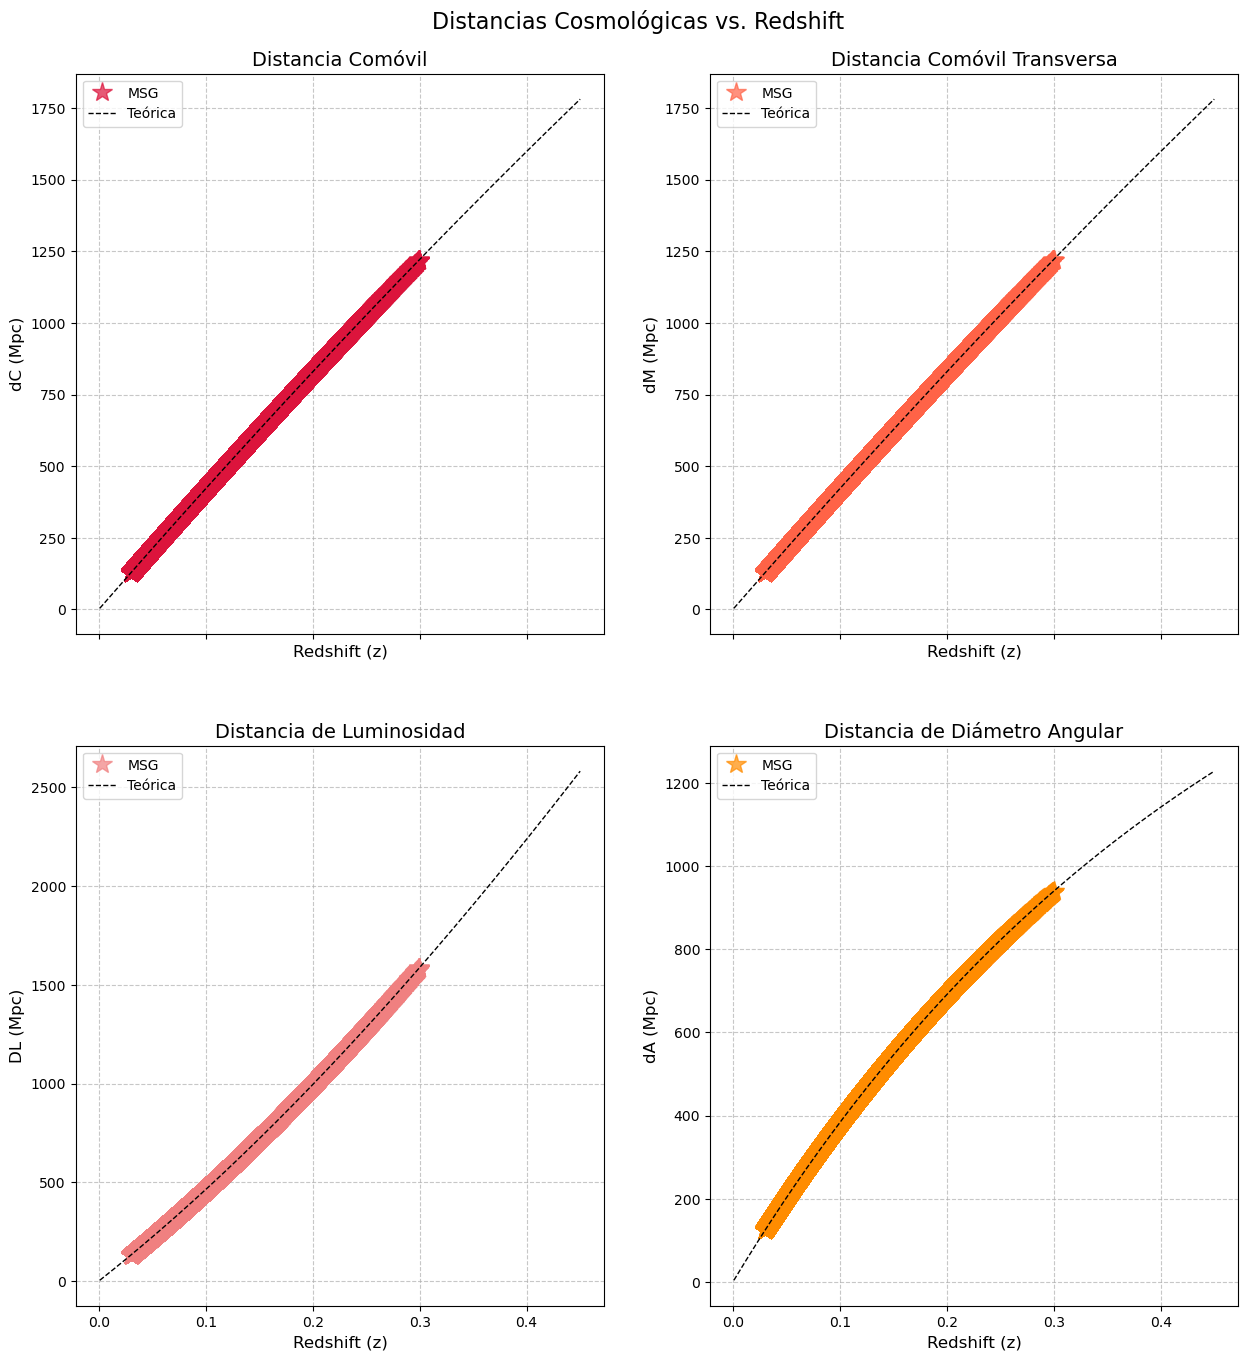

In [41]:
#redshift de MSG
redshift = redshift

#generar datos teoricos de redshift
#redshift maximo de los datos teoricos
z_data_max = 0.4
z_theoretical_values = np.linspace(0.001, z_data_max + 0.05, 200)

#calcular las curvas teoricas
dL_theoretical = cosmo.luminosity_distance(z_theoretical_values)
dC_theoretical = cosmo.comoving_distance(z_theoretical_values)
dM_theoretical = cosmo.comoving_transverse_distance(z_theoretical_values)
dA_theoretical = cosmo.angular_diameter_distance(z_theoretical_values)

# crear los plots de cada distancia vs redshift
fig, axs = plt.subplots(2, 2, figsize=(15, 16), sharex=True) #2 filas, 2 columnas, comparten eje x (sharex=True)
fig.suptitle('Distancias Cosmológicas vs. Redshift', y=0.92, fontsize=16)

#plot 1 : Distancia Comóvil (dC)
axs[0,0].plot(redshift, Comoving_dist, '*', color='crimson', markersize=15, alpha=0.7, label='MSG') #datos MSG
axs[0,0].plot(z_theoretical_values, dC_theoretical, color='black', linewidth=1, linestyle='--', label='Teórica') #curva teórica
axs[0,0].set_ylabel('dC (Mpc)', fontsize=12)
axs[0,0].set_title('Distancia Comóvil', fontsize=14)
axs[0,0].grid(True, linestyle='--', alpha=0.7)
axs[0,0].set_xlabel('Redshift (z)', fontsize=12)
axs[0,0].legend(fontsize=10) #leyenda

#plot 2: Distancia Comóvil Transversa (dM)
#Para un universo plano (como FlatLambdaCDM), dM y dC son iguales.
axs[0,1].plot(redshift, dM, '*', color='tomato', markersize=15, alpha=0.7, label='MSG')
axs[0,1].plot(z_theoretical_values, dM_theoretical, color='black', linewidth=1, linestyle='--', label='Teórica')
axs[0,1].set_ylabel('dM (Mpc)', fontsize=12)
axs[0,1].set_title('Distancia Comóvil Transversa', fontsize=14)
axs[0,1].grid(True, linestyle='--', alpha=0.7)
axs[0,1].set_xlabel('Redshift (z)', fontsize=12)
axs[0,1].legend(fontsize=10)

#plot 3: Distancia de Luminosidad (DL)
axs[1,0].plot(redshift, LD, '*', color='lightcoral', markersize=15, alpha=0.7, label='MSG')
axs[1,0].plot(z_theoretical_values, dL_theoretical, color='black', linewidth=1, linestyle='--', label='Teórica')
axs[1,0].set_ylabel('DL (Mpc)', fontsize=12)
axs[1,0].set_title('Distancia de Luminosidad', fontsize=14)
axs[1,0].grid(True, linestyle='--', alpha=0.7)
axs[1,0].set_xlabel('Redshift (z)', fontsize=12)
axs[1,0].legend(fontsize=10)

#plot 4: Distancia de Diámetro Angular (dA)
axs[1,1].plot(redshift, dA, '*', color='darkorange', markersize=15, alpha=0.7, label='MSG') 
axs[1,1].plot(z_theoretical_values, dA_theoretical, color='black', linewidth=1, linestyle='--', label='Teórica')
axs[1,1].set_ylabel('dA (Mpc)', fontsize=12)
axs[1,1].set_title('Distancia de Diámetro Angular', fontsize=14)
axs[1,1].grid(True, linestyle='--', alpha=0.7)
axs[1,1].set_xlabel('Redshift (z)', fontsize=12)
axs[1,1].legend(fontsize=10)

#ajustar el espacio entre subplots para que no se superpongan
plt.subplots_adjust(hspace=0.2, wspace=0.2)

plt.show()

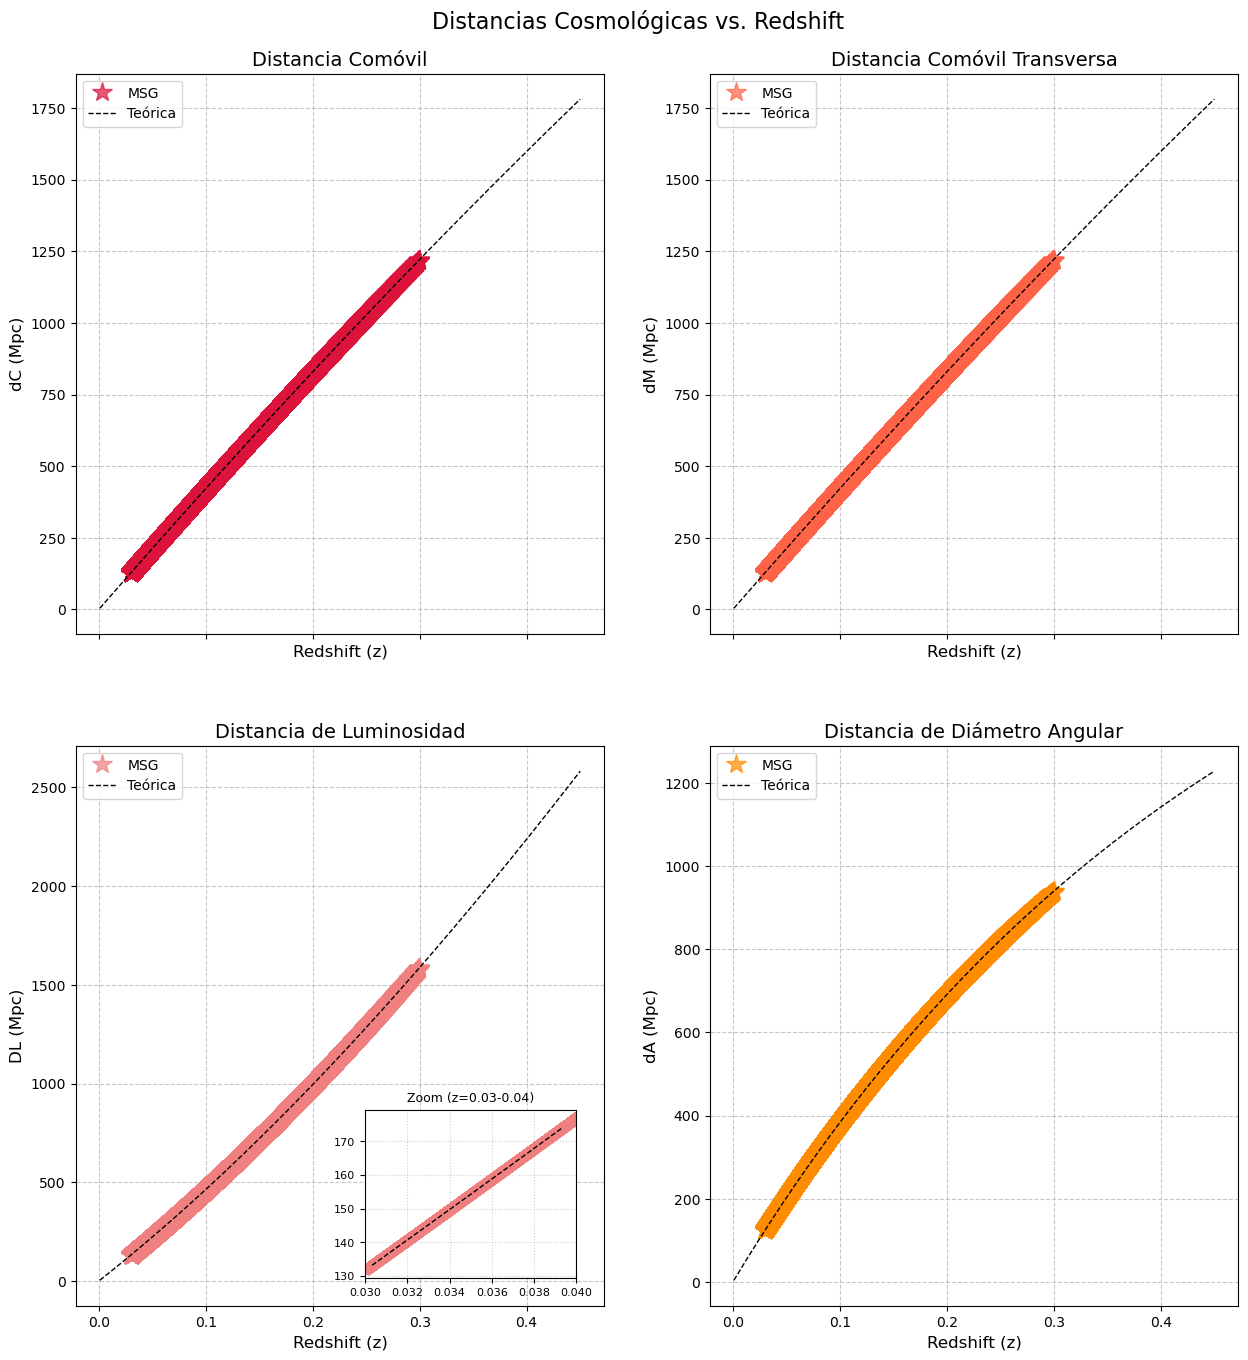

In [47]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes # ¡Importa esto!

# generar datos teoricos de redshift
# redshift maximo de los datos teoricos
z_data_max = 0.4
z_theoretical_values = np.linspace(0.001, z_data_max + 0.05, 200)

# calcular las curvas teoricas
dL_theoretical = cosmo.luminosity_distance(z_theoretical_values)
dC_theoretical = cosmo.comoving_distance(z_theoretical_values)
dM_theoretical = cosmo.comoving_transverse_distance(z_theoretical_values)
dA_theoretical = cosmo.angular_diameter_distance(z_theoretical_values)

# crear los plots de cada distancia vs redshift
fig, axs = plt.subplots(2, 2, figsize=(15, 16), sharex=True) #2 filas, 2 columnas, comparten eje x (sharex=True)
fig.suptitle('Distancias Cosmológicas vs. Redshift', y=0.92, fontsize=16)

# plot 1 : Distancia Comóvil (dC)
axs[0,0].plot(redshift, Comoving_dist, '*', color='crimson', markersize=15, alpha=0.7, label='MSG') #datos MSG
axs[0,0].plot(z_theoretical_values, dC_theoretical, color='black', linewidth=1, linestyle='--', label='Teórica') #curva teórica
axs[0,0].set_ylabel('dC (Mpc)', fontsize=12)
axs[0,0].set_title('Distancia Comóvil', fontsize=14)
axs[0,0].grid(True, linestyle='--', alpha=0.7)
axs[0,0].set_xlabel('Redshift (z)', fontsize=12)
axs[0,0].legend(fontsize=10) #leyenda

# plot 2: Distancia Comóvil Transversa (dM)
# Para un universo plano (como FlatLambdaCDM), dM y dC son iguales.
axs[0,1].plot(redshift, dM, '*', color='tomato', markersize=15, alpha=0.7, label='MSG')
axs[0,1].plot(z_theoretical_values, dM_theoretical, color='black', linewidth=1, linestyle='--', label='Teórica')
axs[0,1].set_ylabel('dM (Mpc)', fontsize=12)
axs[0,1].set_title('Distancia Comóvil Transversa', fontsize=14)
axs[0,1].grid(True, linestyle='--', alpha=0.7)
axs[0,1].set_xlabel('Redshift (z)', fontsize=12)
axs[0,1].legend(fontsize=10)

# plot 3: Distancia de Luminosidad (DL) (aquí se agrega el inset plot)
ax_dl = axs[1,0] #se asignamos el subplot a una variable para mayor claridad

ax_dl.plot(redshift, LD, '*', color='lightcoral', markersize=15, alpha=0.7, label='MSG')
ax_dl.plot(z_theoretical_values, dL_theoretical, color='black', linewidth=1, linestyle='--', label='Teórica')
ax_dl.set_ylabel('DL (Mpc)', fontsize=12)
ax_dl.set_title('Distancia de Luminosidad', fontsize=14)
ax_dl.grid(True, linestyle='--', alpha=0.7)
ax_dl.set_xlabel('Redshift (z)', fontsize=12)
ax_dl.legend(fontsize=10)

#INSET PLOT para Distancia de Luminosidad ---
#definir el rango de redshift para el inset plot
z_inset_min = 0.03
z_inset_max = 0.04

#cear los ejes para el inset plot
# bbox_to_anchor: posición del inset en el espacio de coordenadas del padre (0,0 es abajo-izquierda, 1,1 es arriba-derecha)
# loc: ubicación de la esquina del inset con respecto a bbox_to_anchor (1=arriba-derecha, 2=arriba-izquierda, etc.)
# borderpad: margen alrededor del inset
axins = inset_axes(ax_dl, width="40%", height="30%", loc='lower right', borderpad=2)

#filtrar los datos para el rango del inset plot
#datos de observación MSG
mask_obs_inset = (redshift >= z_inset_min) & (redshift <= z_inset_max)
axins.plot(redshift[mask_obs_inset], LD[mask_obs_inset], '*', color='lightcoral', markersize=8, alpha=0.9)

#curva teórica
mask_theor_inset = (z_theoretical_values >= z_inset_min) & (z_theoretical_values <= z_inset_max)
axins.plot(z_theoretical_values[mask_theor_inset], dL_theoretical[mask_theor_inset], color='black', linewidth=1, linestyle='--')

#configurar el inset plot
axins.set_xlim(z_inset_min, z_inset_max)
# axins.set_ylim(...) #opcional: si se quiere fijar los límites del eje Y del inset
axins.set_title(f'Zoom (z={z_inset_min}-{z_inset_max})', fontsize=9)
axins.tick_params(axis='x', labelsize=8)
axins.tick_params(axis='y', labelsize=8)
axins.grid(True, linestyle=':', alpha=0.6)

# plot 4: Distancia de Diámetro Angular (dA)
axs[1,1].plot(redshift, dA, '*', color='darkorange', markersize=15, alpha=0.7, label='MSG')
axs[1,1].plot(z_theoretical_values, dA_theoretical, color='black', linewidth=1, linestyle='--', label='Teórica')
axs[1,1].set_ylabel('dA (Mpc)', fontsize=12)
axs[1,1].set_title('Distancia de Diámetro Angular', fontsize=14)
axs[1,1].grid(True, linestyle='--', alpha=0.7)
axs[1,1].set_xlabel('Redshift (z)', fontsize=12)
axs[1,1].legend(fontsize=10)

# Ajustar el espacio entre subplots para que no se superpongan
plt.subplots_adjust(hspace=0.2, wspace=0.2) # Ajusta este valor para más o menos espacio

# Mostrar la gráfica
plt.show()